In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA




Vamos fazer isto de forma diferente. Estava a abordar mal a coisa, e os resultados não estavam a ser bons. Já percebi o que fazer e como fazer.

In [14]:
dataset = pd.read_csv('Pokemon.csv', index_col = 0)

dataset.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [15]:
dataset.columns

Index(['Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='str')

In [16]:
dataset.isna().sum()

Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [25]:
dataset["physical_bulk"] = np.log1p(dataset["HP"] * dataset["Defense"])
dataset["special_bulk"] = np.log1p(dataset["HP"] * dataset["Sp. Def"])
dataset["best_offense"] = dataset[["Attack", "Sp. Atk"]].max(axis = 1)
dataset["offense_bias"] = dataset["Attack"] - dataset["Sp. Atk"]

#só para dar commit

In [18]:
dataset_num = dataset.select_dtypes(include= 'number')
dataset_cat = dataset.select_dtypes(exclude = 'number')

dataset_num.head()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,physical_bulk,special_bulk,best_offense,offense_bias
#,,,,,,,,,,,,
1,318,45,49,49,65,65,45,1,2205,45,65,-16
2,405,60,62,63,80,80,60,1,3780,60,80,-18
3,525,80,82,83,100,100,80,1,6640,80,100,-18
3,625,80,100,123,122,120,80,1,9840,80,122,-22
4,309,39,52,43,60,50,65,1,1677,39,60,-8


In [19]:
dataset_num.drop(['Total', 'Generation'], axis = 1, inplace=True)


In [20]:
scaler = StandardScaler()

num_scaled = scaler.fit_transform(dataset_num) #this returns by itself an array

#we need to put it as a dataframe so that we can merge with the categorical data
num_scaled = pd.DataFrame(num_scaled, columns=dataset_num.columns, index = dataset.index)


dataset_scaled = pd.concat([dataset_cat, num_scaled], axis=1)

features = dataset

In [30]:
k_range = range(2,9)

dispersion = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled)
    dispersion.append(kmeans.inertia_)

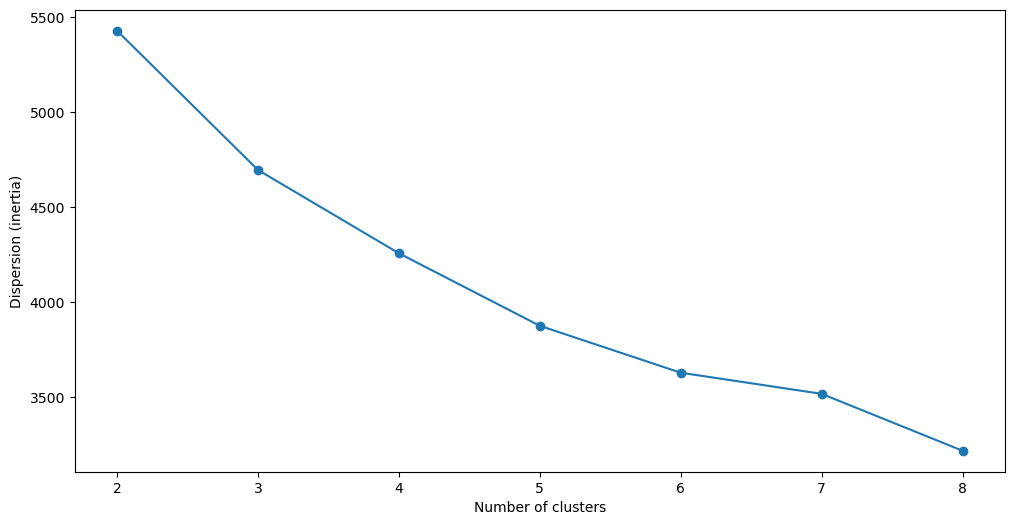

In [31]:
plt.figure(figsize=(12,6))
plt.plot(k_range, dispersion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

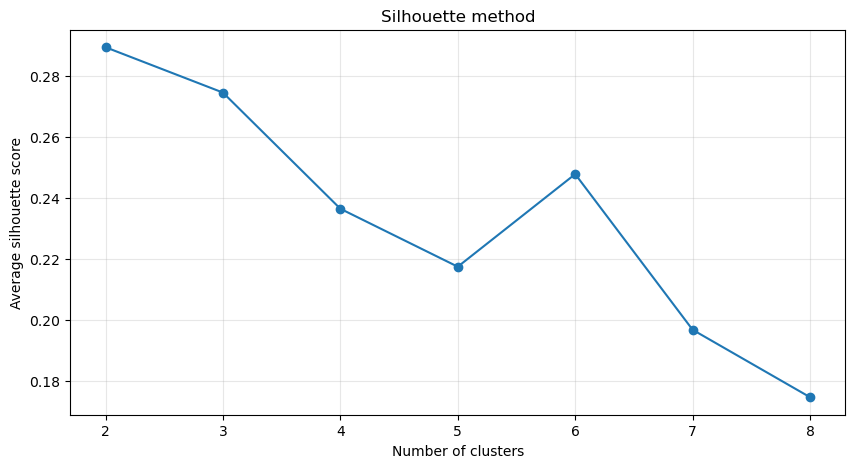

In [44]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(num_scaled)
    score = silhouette_score(num_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Average silhouette score')
plt.title('Silhouette method')
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Best number of clusters: {best_k}")

Best number of clusters: 2


In [33]:
dataset['cluster'] = labels

In [38]:
dataset_original = dataset.groupby("cluster")[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].mean()
dataset_original

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
cluster,,,,,,
0,116.177419,77.967742,76.193548,79.645161,86.112903,58.596774
1,58.794872,76.358974,64.136752,46.179487,49.136752,50.350427
2,58.965517,71.568966,118.948276,72.741379,106.637931,51.551724
3,80.840909,96.704545,84.511364,132.795455,98.897727,93.829545
4,76.970588,117.186275,82.784314,65.313725,74.313725,84.245098
5,46.164835,44.412088,46.357143,48.840659,49.884615,50.752747
6,100.115385,129.500000,127.750000,88.096154,89.307692,73.057692
7,67.136691,71.956835,64.647482,85.453237,73.690647,87.928058


In [39]:
dataset_new = dataset.groupby("cluster")[["physical_bulk", "special_bulk", "best_offense", "offense_bias"]].mean()
dataset_new

,physical_bulk,special_bulk,best_offense,offense_bias
cluster,,,,
0,8.979985,9.149656,87.741935,-1.677419
1,8.131344,7.878151,76.521368,30.179487
2,8.798905,8.667112,81.568966,-1.172414
3,8.783902,8.936855,132.965909,-36.090909
4,8.714614,8.613634,117.186275,51.872549
5,7.572918,7.649694,53.549451,-4.428571
6,9.408808,9.044759,130.750000,41.403846
7,8.338715,8.468539,88.733813,-13.496403


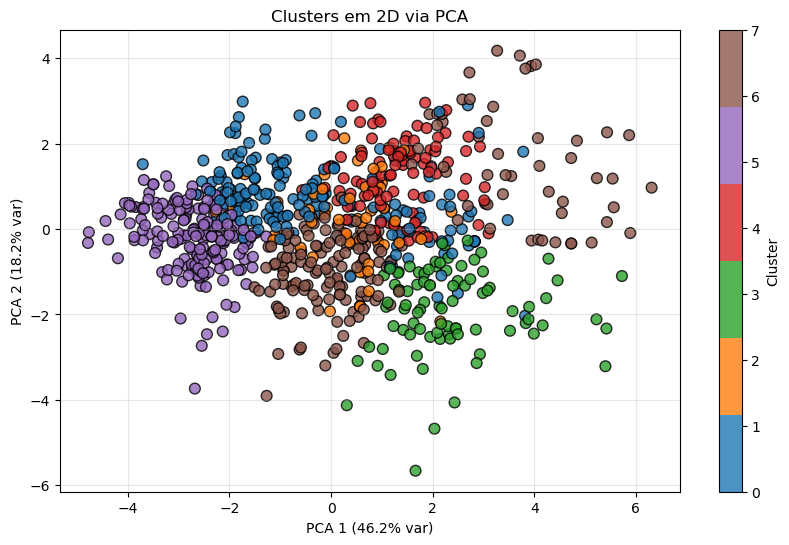

In [42]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels,
            cmap=cmap,
            s=60,
            alpha=0.8,
            edgecolor='k')

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('Clusters em 2D via PCA')
plt.colorbar(ticks=range(len(np.unique(labels))), label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

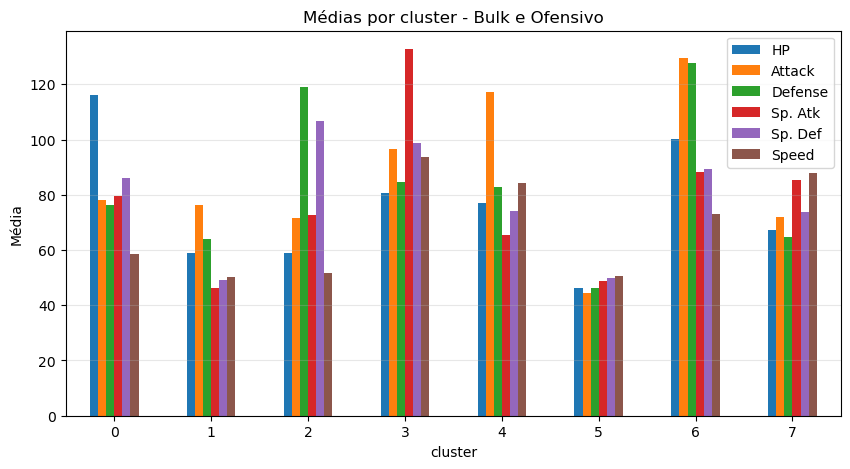

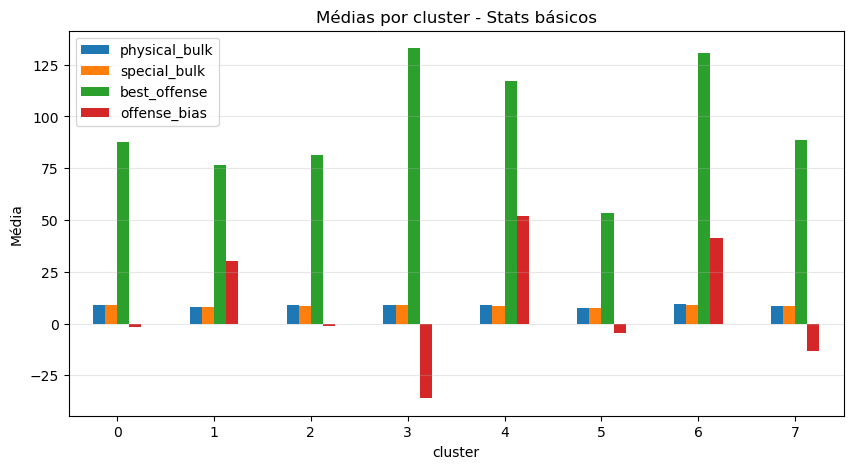

In [41]:
dataset_original.plot(kind='bar', figsize=(10, 5))
plt.title('Médias por cluster - Bulk e Ofensivo')
plt.ylabel('Média')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

dataset_new.plot(kind='bar', figsize=(10, 5))
plt.title('Médias por cluster - Stats básicos')
plt.ylabel('Média')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
#TESTE

In [45]:
# Create more meaningful features
dataset["physical_bulk"] = np.log1p(dataset["HP"] * dataset["Defense"])
dataset["special_bulk"] = np.log1p(dataset["HP"] * dataset["Sp. Def"])
dataset["best_offense"] = dataset[["Attack", "Sp. Atk"]].max(axis=1)
dataset["offense_bias"] = dataset["Attack"] - dataset["Sp. Atk"]

# Use only relevant features
features_to_use = ["physical_bulk", "special_bulk", "best_offense", "offense_bias", "Speed"]
num_scaled = scaler.fit_transform(dataset[features_to_use])

In [46]:
# Try MinMaxScaler instead of StandardScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_scaled = scaler.fit_transform(dataset_num)

In [47]:
# Hierarchical clustering often gives better results
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels = agg.fit_predict(num_scaled)

In [48]:
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
labels = kmeans.fit_predict(num_scaled)

In [49]:
# Remove extreme values that mess up clusters
Q1 = dataset_num.quantile(0.25)
Q3 = dataset_num.quantile(0.75)
IQR = Q3 - Q1
dataset_clean = dataset_num[~((dataset_num < (Q1 - 1.5 * IQR)) | (dataset_num > (Q3 + 1.5 * IQR))).any(axis=1)]

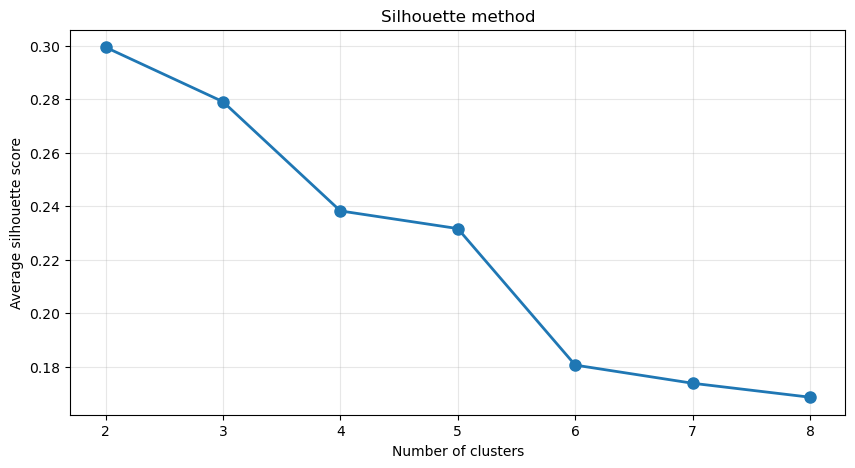

Best number of clusters: 2
Best silhouette score: 0.299


In [50]:
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(num_scaled)
    score = silhouette_score(num_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of clusters')
plt.ylabel('Average silhouette score')
plt.title('Silhouette method')
plt.grid(True, alpha=0.3)
plt.show()

# Find the best k
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Best number of clusters: {best_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

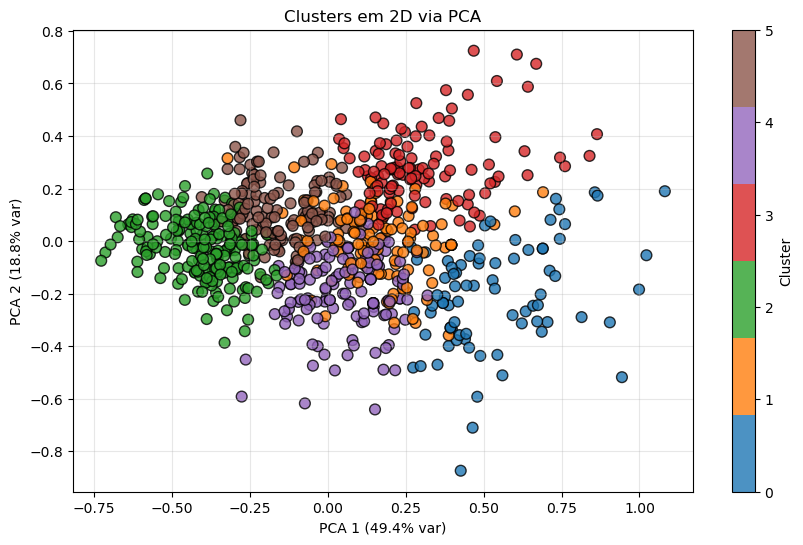

In [52]:
# Set clusters to 2
best_k = 6

# Re-run KMeans with best_k=2
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(num_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)

# Visualize
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels,
            cmap=cmap,
            s=60,
            alpha=0.8,
            edgecolor='k')

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('Clusters em 2D via PCA')
plt.colorbar(ticks=range(len(np.unique(labels))), label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

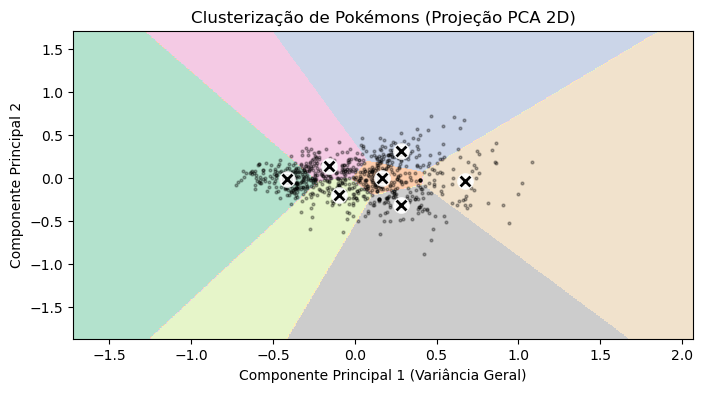

In [57]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=4, alpha=0.3)

def plot_centroids(centroids, weights=None):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]

    plt.scatter(centroids[:, 0], centroids[:, 1], marker='o', s=100, linewidths=2, color='w', zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=50, linewidths=2, color='k', zorder=11, alpha=1)

def plot_clusters(clusterer, X):
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1
    res = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, res), np.arange(y_min, y_max, res))

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(xx.min(), xx.max(), yy.min(), yy.max()), 
                 cmap=plt.cm.Pastel2, origin='lower')

    plot_data(X)
    plot_centroids(clusterer.cluster_centers_)

    plt.title("Clusterização de Pokémons (Projeção PCA 2D)")
    plt.xlabel("Componente Principal 1 (Variância Geral)")
    plt.ylabel("Componente Principal 2")


pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)

kmeans_pca = KMeans(n_clusters=7, n_init=10, random_state=42)
kmeans_pca.fit(X_pca)

plt.figure(figsize=(8,4))
plot_clusters(kmeans_pca, X_pca)
plt.show()